# Course network — interactive 2D / 3D graph

**Workflow:** edit **Cell 1** only (nodes + edges), then *Run All*. Cell 2 holds settings, Cell 3 the machinery, Cell 4 builds everything.

Outputs (also saved as standalone HTML in `OUT_DIR`):
1. **pyvis 2D** — live physics, drag nodes, edge lengths ∝ distance derived from weight; starts from the optimised layout.
2. **Plotly 2D** — static optimised layout, boxed labels, zoom/pan/hover.
3. **Plotly 3D** — optimised 3D layout, rotate/zoom/hover.

The 2D/3D positions come from a **Kamada–Kawai** layout: it minimises stress, i.e. it tries to make every Euclidean node distance match the graph-theoretic (shortest-path) distance, where each edge has length `WEIGHT_TO_DISTANCE(weight)`.

In [1]:
# ================= CELL 1 — NETWORK DEFINITION (edit here) =================
# NODES:  ID -> "Display name"                 (group = None)
#   ID = short abbreviation shown in the box (BOX_TEXT = "id"); the full name appears on hover
#     or  ID -> ("Display name", "Group")        (group sets the colour)
#     or  ID -> ("Display name", "Group", importance)   (importance > 0 sets the node size;
#                                                        missing -> DEFAULT_IMPORTANCE)
NODES = {
    "GT":    ("Graph theory basics",          "Foundations", 3),
    "MAT":   ("Adjacency & Laplacian",        "Foundations", 3),
    "DEG":   ("Degree distributions",         "Foundations", 3),
    "PATH":  ("Paths & distances",            "Foundations", 3),
    "ER":    ("Erdős–Rényi random graphs",    "Models", 1),
    "WS":    ("Small-world networks",         "Models", 1),
    "BA":    ("Scale-free networks",          "Models", 1),
    "CENT":  ("Centrality measures",          "Structure", 2),
    "CLU":   ("Clustering coefficient",       "Structure", 2),
    "COM":   ("Community detection",          "Structure", 2),
    "MOD":   ("Modularity",                   "Structure", 2),
    "SPEC":  ("Spectral graph analysis",      "Dynamics", 1),
    "SYNC":  ("Synchronisation (Kuramoto)",   "Dynamics", 1),
    "EPI":   ("Epidemic spreading",           "Dynamics", 1),
    "BRAIN": ("Brain networks from EEG",      "Applications", 5),
}

# EDGES: (source ID, target ID, weight)
# weight = strength of the relation: larger weight -> nodes placed closer together
EDGES = [
    ("GT",   "MAT",   1.0),
    ("GT",   "DEG",   0.9),
    ("GT",   "PATH",  0.9),
    ("MAT",  "SPEC",  1.0),
    ("DEG",  "ER",    0.8),
    ("DEG",  "BA",    1.0),
    ("PATH", "WS",    0.8),
    ("PATH", "CENT",  0.7),
    ("ER",   "WS",    0.6),
    ("ER",   "BA",    0.5),
    ("WS",   "CLU",   0.9),
    ("CLU",  "COM",   0.5),
    ("CENT", "BRAIN", 0.4),
    ("COM",  "MOD",   1.0),
    ("MOD",  "SPEC",  0.6),
    ("SPEC", "SYNC",  0.8),
    ("MAT",  "SYNC",  0.4),
    ("WS",   "SYNC",  0.5),
    ("BA",   "EPI",   0.8),
    ("DEG",  "EPI",   0.5),
    ("SYNC", "BRAIN", 0.9),
    ("COM",  "BRAIN", 0.6),
    ("SPEC", "BRAIN", 0.4),
]


In [2]:
# ================= CELL 2 — SETTINGS =================
DIRECTED    = True                  # True: arrows in the pyvis graph (layout itself is undirected)
WEIGHT_TO_DISTANCE = lambda w: 1.0 / w   # how weight becomes target edge length
LAYOUT      = "kamada_kawai"         # "kamada_kawai" (stress minimisation) or "spring" (Fruchterman–Reingold)
SEED        = 1                      # fixes the layout between runs
BOX_TEXT    = "id"                   # text inside the node boxes: "id" (abbreviation) or "name" (full name)
LABEL_WRAP  = 16                     # characters per label line
OUT_DIR     = "network_output"       # standalone HTML files go here
TITLE       = "Network science course"

PYVIS_PX_PER_UNIT = 140              # pyvis edge length (px) per unit distance
PYVIS_PHYSICS_PANEL = False          # True: show vis.js physics sliders under the graph
PLOT_HEIGHT = 750

# Node importance -> node size (box area proportional to importance by default)
DEFAULT_IMPORTANCE = 1               # used when a node has no importance given
FONT_MIN, FONT_MAX = 11, 22          # label font size (px) range in Plotly; boxes scale with the font
PYVIS_FONT_FACTOR  = 1.5             # pyvis zooms out to fit the canvas, so its fonts need to be larger
SIZE_EXPONENT = 0.5                  # 0.5: box AREA ∝ importance;  1: box WIDTH ∝ importance;  0: all equal

# Fixed categorical colour order (assigned to groups in order of first appearance)
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
DEFAULT_COLOR = "#6b6b66"            # nodes without a group


In [3]:
# ================= CELL 3 — MACHINERY (no need to edit) =================
import os, textwrap, warnings
import numpy as np
import networkx as nx
import plotly.graph_objects as go
from pyvis.network import Network
from IPython.display import IFrame, display


def build_graph(nodes, edges):
    """Validate the definitions and return an undirected nx.Graph."""
    G = nx.Graph()
    for nid, spec in nodes.items():
        if isinstance(spec, str):
            spec = (spec,)
        label, group, imp = (tuple(spec) + (None, DEFAULT_IMPORTANCE))[:3]
        if not (isinstance(imp, (int, float)) and imp > 0):
            raise ValueError(f"NODES['{nid}']: importance must be a positive number (got {imp!r})")
        G.add_node(nid, label=label, group=group, importance=float(imp))
    seen = set()
    for i, e in enumerate(edges):
        if len(e) != 3:
            raise ValueError(f"EDGES[{i}] = {e!r}: expected (source, target, weight)")
        u, v, w = e
        if u == v:
            warnings.warn(f"EDGES[{i}]: self-loop {u} ignored"); continue
        if w <= 0:
            raise ValueError(f"EDGES[{i}] {u}-{v}: weight must be > 0 (got {w})")
        for n in (u, v):
            if n not in G:
                warnings.warn(f"EDGES[{i}]: node '{n}' not in NODES — added with its ID as name")
                G.add_node(n, label=n, group=None, importance=float(DEFAULT_IMPORTANCE))
        key = frozenset((u, v))
        if key in seen:
            warnings.warn(f"EDGES[{i}]: duplicate edge {u}-{v}, last weight ({w}) kept")
        seen.add(key)
        G.add_edge(u, v, weight=float(w), dist=float(WEIGHT_TO_DISTANCE(w)))
    iso = list(nx.isolates(G))
    if iso:
        print("Note — isolated nodes (no edges):", iso)
    return G


def compute_layout(G, dim):
    if LAYOUT == "kamada_kawai":
        # seed the optimiser with a spring layout so results are reproducible
        p0 = nx.spring_layout(G, dim=dim, seed=SEED)
        pos = nx.kamada_kawai_layout(G, weight="dist", dim=dim, pos=p0)
    elif LAYOUT == "spring":
        pos = nx.spring_layout(G, dim=dim, weight="weight", seed=SEED, iterations=500)
    else:
        raise ValueError(f"unknown LAYOUT {LAYOUT!r}")
    return {n: np.asarray(p, float) for n, p in pos.items()}


def layout_fit(G, pos):
    """Correlation between target distance (weighted shortest path) and drawn distance, over all connected pairs."""
    sp = dict(nx.all_pairs_dijkstra_path_length(G, weight="dist"))
    t, d = [], []
    nodes = list(G)
    for i, a in enumerate(nodes):
        for b in nodes[i + 1:]:
            if b in sp[a]:
                t.append(sp[a][b]); d.append(np.linalg.norm(pos[a] - pos[b]))
    return np.corrcoef(t, d)[0, 1] if len(t) > 2 else np.nan


def group_colors(G):
    groups = []
    for _, g in G.nodes(data="group"):
        if g is not None and g not in groups:
            groups.append(g)
    if len(groups) > len(PALETTE):
        warnings.warn(f"{len(groups)} groups but {len(PALETTE)} colours — extra groups reuse colours")
    return {g: PALETTE[i % len(PALETTE)] for i, g in enumerate(groups)}


def node_scale(G):
    """Return f(node) -> value in [0, 1]: (importance / max importance) ** SIZE_EXPONENT."""
    imax = max(G.nodes[n]["importance"] for n in G) if len(G) else 1.0
    return lambda n: (G.nodes[n]["importance"] / imax) ** SIZE_EXPONENT


def font_size(G, n, s):
    return max(FONT_MIN, round(FONT_MAX * s(n), 1))


def wrap(s, sep):
    return sep.join(textwrap.wrap(s, LABEL_WRAP)) or s


def box_text(G, n, sep):
    """Text inside the node box: the ID (abbreviation) or the wrapped full name."""
    return n if BOX_TEXT == "id" else wrap(G.nodes[n]["label"], sep)


def hover_text(G, n, sep):
    d = G.nodes[n]
    s = f"<b>{d['label']}</b>" if sep == "<br>" else d["label"]
    s += f"{sep}ID: {n}"
    if d["group"]: s += f"{sep}Group: {d['group']}"
    s += f"{sep}Importance: {d['importance']:g}"
    s += f"{sep}Degree: {G.degree(n)}   Strength: {G.degree(n, weight='weight'):.2f}"
    return s


def pyvis_2d(G, pos, cmap, fname):
    net = Network(height=f"{PLOT_HEIGHT}px", width="100%", directed=DIRECTED,
                  notebook=True, cdn_resources="in_line", bgcolor="#ffffff")
    wmax = max((w for *_, w in G.edges(data="weight")), default=1)
    s = node_scale(G)
    for n, d in G.nodes(data=True):
        c = cmap.get(d["group"], DEFAULT_COLOR)
        fs = PYVIS_FONT_FACTOR * font_size(G, n, s)
        x, y = pos[n] * PYVIS_PX_PER_UNIT * 2
        net.add_node(n, label=box_text(G, n, "\n"), title=hover_text(G, n, "\n"),
                     shape="box", margin=round(0.6 * fs), x=float(x), y=float(-y),
                     color={"background": c, "border": c,
                            "highlight": {"background": c, "border": "#222222"}},
                     font={"color": "white", "size": fs, "face": "arial"})
    src = EDGES if DIRECTED else G.edges(data="weight")   # keep the user's direction for arrows
    for u, v, *rest in src:
        if not G.has_edge(u, v): continue
        w = G[u][v]["weight"]
        net.add_edge(u, v, value=None, width=1 + 5 * w / wmax,
                     length=G[u][v]["dist"] * PYVIS_PX_PER_UNIT,
                     title=f"{G.nodes[u]['label']} — {G.nodes[v]['label']}\nweight {w:g}",
                     color={"color": "#9a9a95", "highlight": "#222222"})
    net.barnes_hut(gravity=-4000, central_gravity=0.1, spring_length=PYVIS_PX_PER_UNIT,
                   spring_strength=0.05, damping=0.4, overlap=0.5)
    if PYVIS_PHYSICS_PANEL:
        net.show_buttons(filter_=["physics"])
    net.write_html(fname, notebook=False)
    return fname


def plotly_fig(G, pos, cmap, dim):
    is3d = dim == 3
    wmax = max((w for *_, w in G.edges(data="weight")), default=1)
    Sc = go.Scatter3d if is3d else go.Scatter
    coords = lambda P: dict(zip("xyz"[:dim], np.asarray(P).T))
    traces = []

    # edges: one line trace per edge (width encodes weight)
    for u, v, w in G.edges(data="weight"):
        traces.append(Sc(**coords([pos[u], pos[v]]), mode="lines", hoverinfo="skip",
                         showlegend=False, line=dict(width=1 + 5 * w / wmax, color="#b4b4ae")))
    # edge hover: invisible points at edge midpoints
    if G.number_of_edges():
        mids = [(pos[u] + pos[v]) / 2 for u, v in G.edges()]
        txt = [f"{G.nodes[u]['label']} — {G.nodes[v]['label']}<br>weight {w:g}"
               for u, v, w in G.edges(data="weight")]
        traces.append(Sc(**coords(mids), mode="markers", hovertext=txt, hoverinfo="text",
                         showlegend=False, marker=dict(size=8 if not is3d else 4, opacity=0)))

    # nodes: one trace per group -> legend
    groups = {}
    for n, g in G.nodes(data="group"):
        groups.setdefault(g, []).append(n)
    s = node_scale(G)
    for g, ns in groups.items():
        c = cmap.get(g, DEFAULT_COLOR)
        traces.append(Sc(**coords([pos[n] for n in ns]), mode="markers", name=g or "(no group)",
                         hovertext=[hover_text(G, n, "<br>") for n in ns], hoverinfo="text",
                         marker=dict(size=[(8 + 16 * s(n)) if not is3d else (3 + 7 * s(n)) for n in ns], color=c,
                                     line=dict(width=2, color="white"))))

    # boxed labels that "contain" the node names
    ann = []
    for n, d in G.nodes(data=True):
        c = cmap.get(d["group"], DEFAULT_COLOR)
        a = dict(text=box_text(G, n, "<br>"), hovertext=hover_text(G, n, "<br>"),
                 hoverlabel=dict(bgcolor=c, font=dict(color="white")), showarrow=False, bgcolor=c, bordercolor=c,
                 borderpad=round(0.35 * font_size(G, n, s)),
                 font=dict(color="white", size=font_size(G, n, s)), opacity=0.92)
        a.update({k: float(val) for k, val in zip("xyz", pos[n])})
        ann.append(a)

    fig = go.Figure(traces)
    hidden = dict(visible=False)
    fig.update_layout(title=f"{TITLE} — {dim}D ({LAYOUT})", template="plotly_white",
                      height=PLOT_HEIGHT, hovermode="closest", legend_title_text="Group",
                      margin=dict(l=10, r=10, t=50, b=10))
    if is3d:
        fig.update_layout(scene=dict(xaxis=hidden, yaxis=hidden, zaxis=hidden,
                                     aspectmode="data", annotations=ann))
    else:
        fig.update_layout(annotations=ann, xaxis=hidden, yaxis=dict(visible=False, scaleanchor="x"))
    return fig


15 nodes, 23 edges, 1 component(s)
Layout fit r(target, drawn distance):  2D = 0.908   3D = 0.975


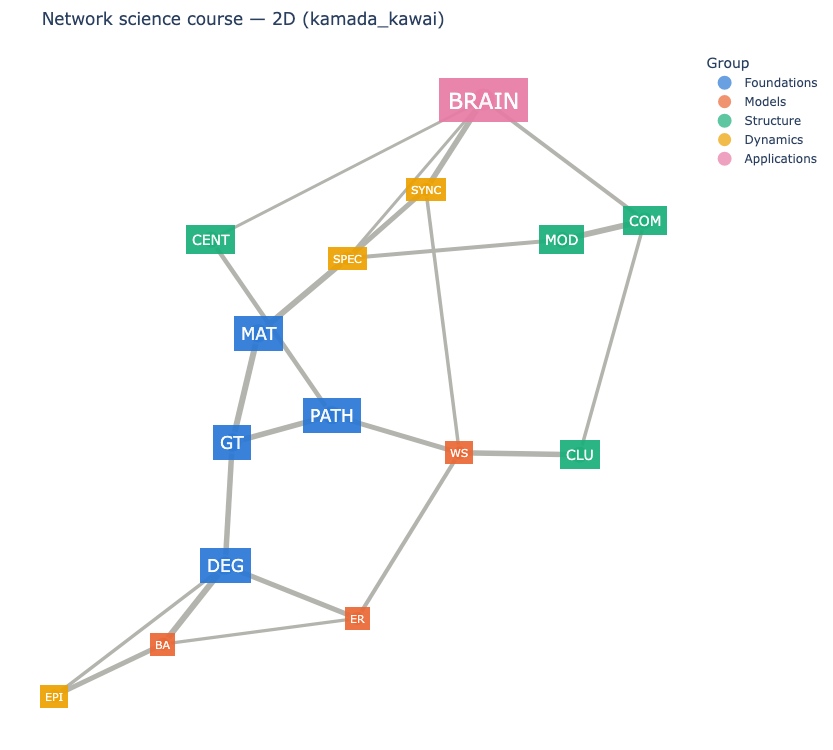

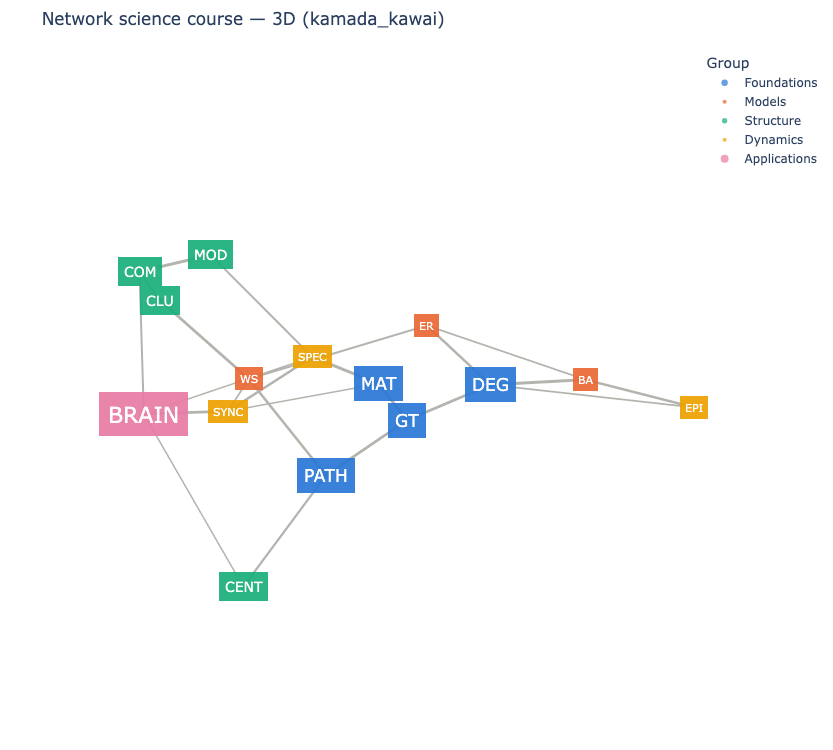

Saved to /Users/geroldbaier/Desktop/Course_Network/network_output


In [4]:
# ================= CELL 4 — BUILD EVERYTHING =================
os.makedirs(OUT_DIR, exist_ok=True)
G = build_graph(NODES, EDGES)
cmap = group_colors(G)
pos2, pos3 = compute_layout(G, 2), compute_layout(G, 3)
print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
      f"{nx.number_connected_components(G)} component(s)")
print(f"Layout fit r(target, drawn distance):  2D = {layout_fit(G, pos2):.3f}   3D = {layout_fit(G, pos3):.3f}")

# 1) pyvis 2D (live physics)
f_pv = pyvis_2d(G, pos2, cmap, os.path.join(OUT_DIR, "network_pyvis_2d.html"))
display(IFrame(f_pv, width="100%", height=PLOT_HEIGHT + 30))

# 2) Plotly 2D
fig2 = plotly_fig(G, pos2, cmap, 2)
fig2.write_html(os.path.join(OUT_DIR, "network_plotly_2d.html"), include_plotlyjs=True)
fig2.show()

# 3) Plotly 3D
fig3 = plotly_fig(G, pos3, cmap, 3)
fig3.write_html(os.path.join(OUT_DIR, "network_plotly_3d.html"), include_plotlyjs=True)
fig3.show()
print("Saved to", os.path.abspath(OUT_DIR))
